# Hypothesis Testing in Python 

This notebook introduces hypothesis testing using real-life examples and built-in Python functions so you can focus on what the test means rather than the math behind it except for Poisson :D

We’ll explore:

- How hypothesis testing connects to confidence intervals

- How to choose the right test

- How to interpret results for business insights

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.weightstats import ztest
from scipy.stats import poisson
np.random.seed(42)
import pandas as pd


## Case Study 1: Binomial Distribution (Proportion Test)

### Scenario:
A new drug is expected to work 60% of the time.
You test it on 20 patients, and 15 show improvement.

Is the success rate significantly different from 60%?

In [2]:
successes = 15
n_trials = 20
expected_rate = 0.6
alpha = 0.05

In [3]:
z_stat, p_value = proportions_ztest(successes, n_trials, value=expected_rate)
print(f"Z-Statistic: {z_stat:.2f}")
print(f"P-Value: {p_value:.4f}")


Z-Statistic: 1.55
P-Value: 0.1213


In [4]:
if p_value < alpha:
    print("Reject H₀: The drug’s success rate is significantly different from 60%.")
else:
    print("Fail to reject H₀: No significant difference from 60%.")


Fail to reject H₀: No significant difference from 60%.


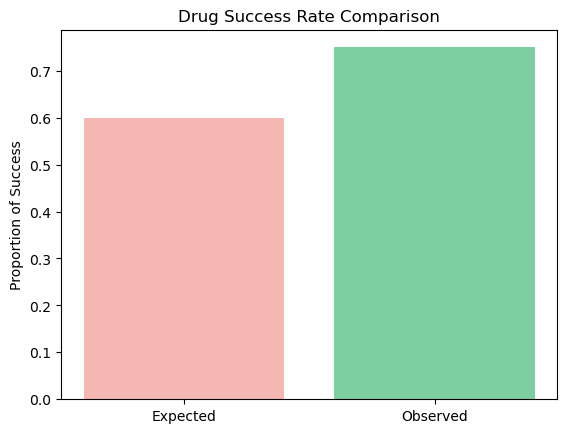

In [5]:
observed_rate = successes / n_trials

plt.bar(["Expected", "Observed"], [expected_rate, observed_rate], color=["#F5B7B1", "#7DCEA0"])
plt.title("Drug Success Rate Comparison")
plt.ylabel("Proportion of Success")
plt.show()


## Case Study 3: Poisson Distribution (Counts)

### Scenario:
Your call center receives an average of 10 calls/hour.
Last hour, you received only 8 calls.
Has the call rate changed?

Step 1: State Hypotheses

- H₀: λ = 10 (no change)

- H₁: λ ≠ 10 (rate has changed)

In [ ]:
# Step 2: Calculate P-Value

# We’ll use the Poisson cumulative distribution to find how likely it is to observe 8 or fewer (or more) calls.

observed_calls = 8
expected_calls = 10

p_value = 2 * min(poisson.cdf(observed_calls, expected_calls),
                  1 - poisson.cdf(observed_calls - 1, expected_calls)) # poisson.cdf(observed_calls, expected_calls): P(X ≤ 8)
                                                                       #1-poisson.cdf(observed_calls - 1, expected_calls): P(X≥8)
print(f"P-Value: {p_value:.4f}")

P-Value: 0.6656


In [7]:
# Poisson probability mass function (PMF)
# P(X=8)=e**(-10)*(10**8)/(8!)

In [28]:
prob_0_to_8=poisson.cdf(observed_calls, expected_calls) # A: P(X ≤ 8)
print(f"P(X<=8): {prob_0_to_8:.4f}")

prob_8 = poisson.pmf(observed_calls, expected_calls)
print(f"P(X=8): {prob_8:.4f}")

prob_8_to_more=1 - poisson.cdf(observed_calls-1, expected_calls) # B: P(X≥8)=1 - P(X ≤ 7)
print(f"P(X>=8): {prob_8_to_more:.4f}")

P(X<=8): 0.3328
P(X=8): 0.1126
P(X>=8): 0.7798


In [ ]:
prob_0_to_7=poisson.cdf(7, expected_calls) # A: P(X ≤ 7)
print(f"P(X<=7): {prob_0_to_7:.4f}")

prob_9_to_more=1 - poisson.cdf(8, expected_calls) # B: P(X≥9)=1 - P(X ≤ 8)
print(f"P(X>=9): {prob_9_to_more:.4f}")

P(X<=7): 0.2202
P(X>=9): 0.6672


In [10]:
# poisson.cdf(k, λ) = P(X≤k)
# P(X≤k), the cumulative probability of observing k or fewer events.
# 1 - poisson.cdf(k-1, λ) = P(X≥k)
# P(X≥k), the probability of observing k or more events.

In [11]:
from scipy.stats import poisson

lambda_ = 10
k = 8

cdf_value_0_to_8 = poisson.cdf(k, lambda_)
print(cdf_value_0_to_8)

cdf_value_0_to_8 = poisson.cdf(k, lambda_)
print(cdf_value_0_to_8)


0.3328196787507191
0.3328196787507191


In [12]:
# This will give P(X ≤ 8).
# Interpretation: It’s the probability that, if the average number of events is 10, you actually see 8 or fewer.
# P(X≤8)=P(X=0)+P(X=1)+⋯+P(X=8)

In [38]:
from scipy.stats import poisson

# 参数
lambda_ = 10   # 平均事件数
k_obs = 8      # 观察到的事件数

# 左尾 p 值
p_left = poisson.cdf(k_obs, mu=lambda_)

# 右尾 p 值
p_right = 1 - poisson.cdf(k_obs - 1, mu=lambda_)

# 双尾 p 值（极端事件概率法）
pmf_obs = poisson.pmf(k_obs, mu=lambda_)
all_probs = [poisson.pmf(k, mu=lambda_) for k in range(0, 50)]  # 足够大范围
p_two_tail = sum(p for p in all_probs if p <= pmf_obs)

# 输出
print(f"p_left: {p_left:.4f}")
print(f"p_right: {p_right:.4f}")
print(f"p_two_tail: {p_two_tail:.4f}")



p_left: 0.3328
p_right: 0.7798
p_two_tail: 0.6360


In [41]:
from scipy.stats import poisson

lambda_ = 10
k_obs = 8

# Left-tailed
p_left = poisson.cdf(k_obs, lambda_)

# Right-tailed
p_right = 1 - poisson.cdf(k_obs - 1, lambda_)

# Two-tailed (manual approach)
p_k = poisson.pmf(k_obs, lambda_)
p_two = sum(poisson.pmf(k, lambda_) for k in range(0, 50) if poisson.pmf(k, lambda_) <= p_k)

print(f"p_left: {p_left:.4f}, p_right: {p_right:.4f}, p_two: {p_two:.4f}")


p_left: 0.3328, p_right: 0.7798, p_two: 0.6360


### Detailed Explanation

#### Step 1: poisson.cdf(observed, expected)

gives the cumulative probability of observing k or fewer events assuming a Poisson distribution with mean λ.

For `poisson.cdf(8, 10)` this calculates:

This is the probability of observing 8 or fewer calls, given the null expectation of 10.

#### Step 2: 1 - poisson.cdf(observed - 1, expected)

`poisson.cdf(observed - 1, expected)` gives 
P(X≤7).

Then `1 - poisson.cdf(observed - 1, expected)` gives:

P(X≥8∣λ=10)

This is the probability of observing 8 or more calls. Notice that because Poisson is discrete, we subtract 1 in the cdf to avoid double-counting the observed value.

#### Step 3: min(...)

For a two-tailed test, the p-value is essentially twice the smaller tail probability, because we want to capture extreme deviations in either direction.

`min(poisson.cdf(observed, expected), 1 - poisson.cdf(observed - 1, expected))` chooses the smaller of the two tail probabilities.

#### Step 4: Multiply by 2

Multiply by 2 to account for both tails (both directions of deviation from the expected value).

`p-value=2×min(P(X≤observed),P(X≥observed))`

### Intuition

If the observed count is much smaller than expected, the lower tail is small → p-value is small → evidence against H₀.

If the observed count is much larger, the upper tail is small → p-value is small → evidence against H₀.

If the observed is close to expected, both tails are relatively large → p-value is large → fail to reject H₀.

In [13]:
if p_value < alpha:
    print("Reject H₀: The average call rate has changed significantly.")
else:
    print("Fail to reject H₀: No significant change in call rate.")


Fail to reject H₀: No significant change in call rate.


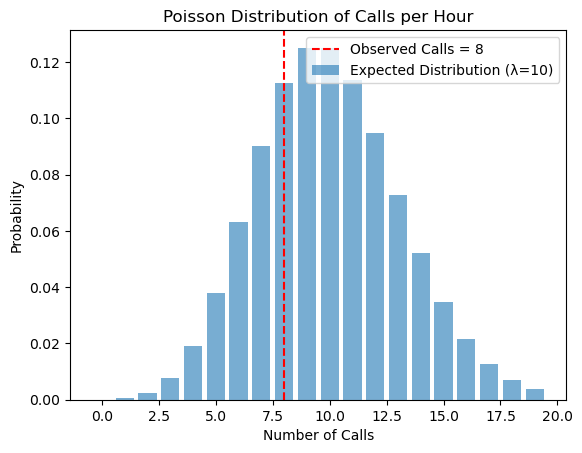

In [14]:
x = np.arange(0, 20)
plt.bar(x, poisson.pmf(x, expected_calls), alpha=0.6, label="Expected Distribution (λ=10)")
plt.axvline(observed_calls, color='red', linestyle='--', label='Observed Calls = 8')
plt.title("Poisson Distribution of Calls per Hour")
plt.xlabel("Number of Calls")
plt.ylabel("Probability")
plt.legend()
plt.show()


# Summary Table

| Test Type               | When to Use                 | Example           | Python Function       |
| ----------------------- | --------------------------- | ----------------- | --------------------- |
| **Z-Test (Mean)**       | Continuous data, known SD   | Bulb lifetime     | `ztest()`             |
| **t-Test (Mean)**       | Continuous data, unknown SD | Small sample mean | `stats.ttest_1samp()` |
| **Z-Test (Proportion)** | Binary data (% or rate)     | Drug success rate | `proportions_ztest()` |
| **Poisson Test**        | Count data                  | Calls per hour    | `poisson.cdf()`       |


## Key Takeaways

Hypothesis testing helps determine whether your sample provides enough evidence to claim a real difference.

- A low p-value (< 0.05) → reject H₀ → “something is likely different.”

- Confidence intervals and hypothesis tests tell similar stories from different angles.

- Always interpret results in context — statistical significance ≠ business significance.

In [15]:
from scipy.stats import poisson

# Suppose the average number of events λ = 3
lambda_ = 3

# Probability of 0, 1, 2, or 3 events (cumulative)
k = 3
prob = poisson.cdf(k, lambda_)
print(prob)

0.6472318887822313


In [16]:
prob_more_than_k = 1 - poisson.cdf(k, lambda_)
prob_more_than_k

np.float64(0.35276811121776874)